# Gaussian beam sanity checks

Demonstrates the Gaussian-beam Rabi frequency implementation:
1. `gaussian_rabi` profile
2. Rabi flops at varying transverse offsets
3. Mach-Zehnder contrast vs cloud radius / beam waist ratio


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path

sys.path.insert(0, str(Path('.').resolve()))
import lmt_simulation as sim

print('RABI_FREQ =', sim.RABI_FREQ, 'Hz')
print('T_PI =', sim.T_PI * 1e6, 'us')
print('RECOIL_FREQUENCY_HZ =', sim.RECOIL_FREQUENCY_HZ, 'Hz')

RABI_FREQ = 11111.111111111111 Hz
T_PI = 44.99999999999999 us
RECOIL_FREQUENCY_HZ = 4707.028607971276 Hz


## 1. Gaussian Rabi profile

Verify `gaussian_rabi` gives `Omega_0` on-axis, `Omega_0/e` at `r = w`, and is negligible at `r = 5w`.

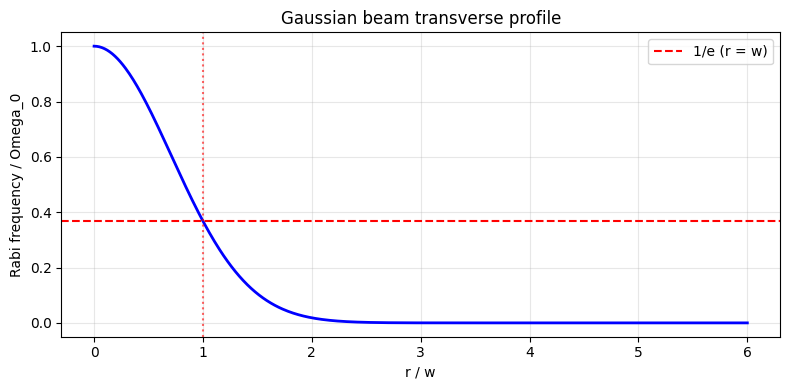

On-axis:  11111.111111  (expected 11111.111111)
At r=w:   4087.549346  (expected 4087.549346)
At r=5w:  1.543e-07  (expected < 1.111e-06)
All spot checks passed.


In [2]:
omega_0 = sim.RABI_FREQ
w = 5e-3  # 5 mm beam waist

r_vals = np.linspace(0, 6 * w, 500)
positions_scan = np.column_stack([r_vals, np.zeros_like(r_vals), np.zeros_like(r_vals)])
rabi_vals = sim.gaussian_rabi(positions_scan, omega_0, w)

plt.figure(figsize=(8, 4))
plt.plot(r_vals / w, rabi_vals / omega_0, 'b-', linewidth=2)
plt.axhline(1.0 / np.e, color='r', linestyle='--', label='1/e (r = w)')
plt.axvline(1.0, color='r', linestyle=':', alpha=0.6)
plt.xlabel('r / w')
plt.ylabel('Rabi frequency / Omega_0')
plt.title('Gaussian beam transverse profile')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()


# Spot checks
pos_center = np.array([[0.0, 0.0, 0.0]])
pos_waist  = np.array([[w,   0.0, 0.0]])
pos_far    = np.array([[5*w, 0.0, 0.0]])

print(f'On-axis:  {sim.gaussian_rabi(pos_center, omega_0, w)[0]:.6f}  (expected {omega_0:.6f})')
print(f'At r=w:   {sim.gaussian_rabi(pos_waist,  omega_0, w)[0]:.6f}  (expected {omega_0/np.e:.6f})')
print(f'At r=5w:  {sim.gaussian_rabi(pos_far,    omega_0, w)[0]:.3e}  (expected < {1e-10*omega_0:.3e})')
assert sim.gaussian_rabi(pos_center, omega_0, w)[0] == omega_0
assert abs(sim.gaussian_rabi(pos_waist, omega_0, w)[0] - omega_0/np.e) < 1e-6 * omega_0
assert sim.gaussian_rabi(pos_far, omega_0, w)[0] < 1e-10 * omega_0
print('All spot checks passed.')

## 2. Rabi flops at varying transverse offsets

Atoms at different radii see a reduced Rabi frequency. The on-axis atom completes a full pi-pulse; atoms further out oscillate with smaller frequency and smaller maximum excitation for longer pulses.

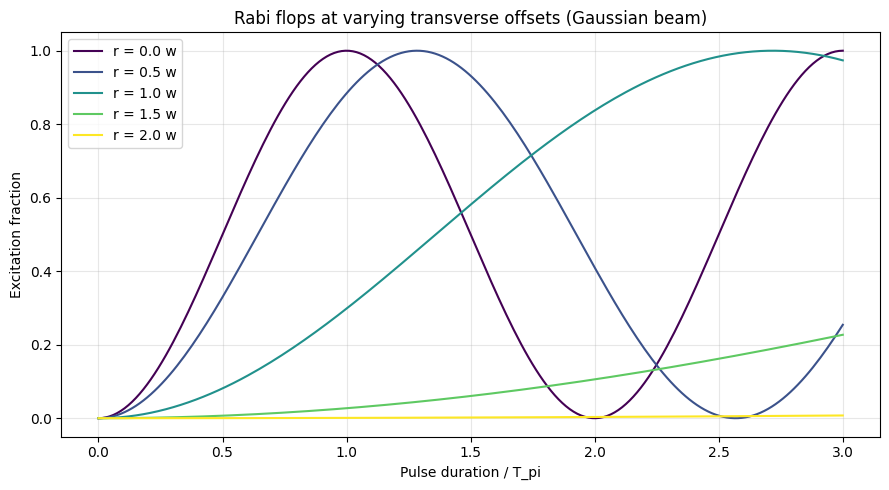

Atoms further from beam axis oscillate slower -- as expected.


In [3]:
w = 5e-3  # 5 mm beam waist
omega_0 = sim.RABI_FREQ
n_pi = 3          # plot over 3 pi-pulse durations
n_pts = 200
t_vals = np.linspace(0, n_pi * sim.T_PI, n_pts)

radii = [0.0, 0.5 * w, w, 1.5 * w, 2.0 * w]
colors = plt.cm.viridis(np.linspace(0, 1, len(radii)))

plt.figure(figsize=(9, 5))
for r, color in zip(radii, colors):
    excitations = []
    for t_pulse in t_vals:
        m_values, positions, velocities, internal_amplitude, internal_is_ground = (
            sim.make_atom_states(position_x=r, c0=1.0, c1=0.0)
        )
        omega_laser = 2 * np.pi * sim.TRANSITION_FREQUENCY
        sq_amp = sim.transform_state_vector(
            m_values, internal_amplitude, internal_is_ground,
            omega_laser=omega_laser, t=0.0, z=0.0, vz=0.0, inverse=False,
        )
        m_out, amp_out, isg_out, pos_out, vel_out = sim.do_gaussian_pulse(
            m_values, sq_amp, internal_is_ground,
            positions, velocities,
            pulse_detuning=sim.RECOIL_FREQUENCY_HZ,
            t_pulse=t_pulse,
            on_axis_rabi_freq=omega_0,
            beam_waist=w,
            vz=0.0,
        )
        amp_lab = sim.transform_state_vector(
            m_out, amp_out, isg_out,
            omega_laser=omega_laser, t=t_pulse, z=0.0, vz=0.0, inverse=True,
        )
        _, exc = sim.calculate_ground_and_excited_probabilities(m_out, amp_lab, isg_out)
        excitations.append(exc)

    plt.plot(t_vals / sim.T_PI, excitations, color=color,
             label=f'r = {r/w:.1f} w')

plt.xlabel('Pulse duration / T_pi')
plt.ylabel('Excitation fraction')
plt.title('Rabi flops at varying transverse offsets (Gaussian beam)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

print('Atoms further from beam axis oscillate slower -- as expected.')

## 3. Mach-Zehnder contrast vs cloud size / beam waist

Sanity check (spec item 7): for a Gaussian atom cloud in a Mach-Zehnder sequence,
inhomogeneous Rabi frequencies across the ensemble reduce the fringe visibility as
the cloud size grows relative to the beam waist.

We compute the fringe visibility by averaging the excited-state probability over
100 atoms drawn from a 2-D Gaussian cloud (sigma = rw * w), for sigma/w from 0 to 3.
A point-like cloud ($\sigma \to 0$) gives contrast ~1; a cloud much larger than the beam
waist gives strongly reduced contrast because atoms at the edges see a much smaller
Rabi frequency than those at the centre.


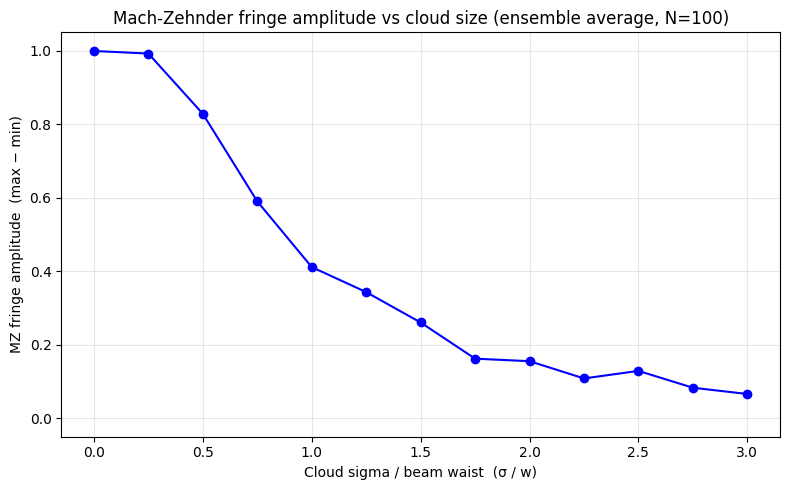

Amplitudes: ['0.999', '0.992', '0.828', '0.590', '0.411', '0.343', '0.261', '0.162', '0.155', '0.109', '0.129', '0.083', '0.066']
On-axis fringe amplitude: 0.9993 (expected ~1.0)
Fringe amplitude at sigma=3w: 0.0662 (expected << on-axis)
Sanity check PASSED.


In [4]:
def mz_excitation_single_atom(phi, x, y, beam_waist,
                               detuning_hz=None, time_between=200e-6):
    """Mach-Zehnder excitation for a single atom at (x, y).

    Runs the standard pi/2 - pi - pi/2 sequence with laser phases 0, phi, 4*phi,
    matching the reference implementation in mach_zehnder_with_temperature.ipynb.
    """
    if detuning_hz is None:
        detuning_hz = sim.RECOIL_FREQUENCY_HZ

    omega_laser = 2 * np.pi * (sim.TRANSITION_FREQUENCY + detuning_hz)
    m_values, positions, velocities, internal_amplitude, internal_is_ground = (
        sim.make_atom_states(position_x=x, position_y=y, c0=1.0, c1=0.0)
    )
    current_time = 0.0

    sq_amp = sim.transform_state_vector(
        m_values, internal_amplitude, internal_is_ground,
        omega_laser=omega_laser, t=0.0, z=0.0, vz=0.0, inverse=False,
    )

    # pi/2 pulse, phase 0
    m_values, sq_amp, internal_is_ground, positions, velocities = (
        sim.do_gaussian_pulse(
            m_values, sq_amp, internal_is_ground, positions, velocities,
            pulse_detuning=detuning_hz, t_pulse=sim.T_PI / 2,
            on_axis_rabi_freq=sim.RABI_FREQ, beam_waist=beam_waist,
            vz=0.0,
        )
    )
    current_time += sim.T_PI / 2

    # Free evolution
    m_values, sq_amp, internal_is_ground, positions, velocities = (
        sim.propagate_states_in_borde_representation(
            m_values, sq_amp, internal_is_ground, positions, velocities,
            time_of_propegation=time_between,
            omega_laser=omega_laser, vz=0.0,
        )
    )
    current_time += time_between

    # pi pulse, phase phi
    m_values, sq_amp, internal_is_ground, positions, velocities = (
        sim.do_gaussian_pulse(
            m_values, sq_amp, internal_is_ground, positions, velocities,
            pulse_detuning=detuning_hz, t_pulse=sim.T_PI,
            on_axis_rabi_freq=sim.RABI_FREQ, beam_waist=beam_waist,
            pulse_phase=phi, vz=0.0,
        )
    )
    current_time += sim.T_PI

    # Free evolution
    m_values, sq_amp, internal_is_ground, positions, velocities = (
        sim.propagate_states_in_borde_representation(
            m_values, sq_amp, internal_is_ground, positions, velocities,
            time_of_propegation=time_between,
            omega_laser=omega_laser, vz=0.0,
        )
    )
    current_time += time_between

    # pi/2 pulse, phase 4*phi
    m_values, sq_amp, internal_is_ground, positions, velocities = (
        sim.do_gaussian_pulse(
            m_values, sq_amp, internal_is_ground, positions, velocities,
            pulse_detuning=detuning_hz, t_pulse=sim.T_PI / 2,
            on_axis_rabi_freq=sim.RABI_FREQ, beam_waist=beam_waist,
            pulse_phase=4 * phi, vz=0.0,
        )
    )
    current_time += sim.T_PI / 2

    amp_lab = sim.transform_state_vector(
        m_values, sq_amp, internal_is_ground,
        omega_laser=omega_laser, t=current_time, z=0.0, vz=0.0, inverse=True,
    )
    gnd, exc = sim.calculate_ground_and_excited_probabilities(
        m_values, amp_lab, internal_is_ground
    )
    # Normalise to handle partial pulses (atoms far from beam axis)
    total = gnd + exc
    return exc / total if total > 1e-15 else 0.0


N_ATOMS = 100
phi_vals = np.linspace(0, 2 * np.pi, 60)
w = 5e-3

rng = np.random.default_rng(42)

# Compute ensemble-averaged fringe for Gaussian clouds with varying sigma.
# Store all fringe curves for use in the fringe-plot cell below.
sigma_over_w = np.linspace(0.0, 3.0, 13)
fringe_curves = {}      # sigma/w -> array of ensemble-averaged excitation vs phi
fringe_per_atom = {}   # sigma/w -> array of shape (n_phi, n_atoms)
amplitudes = []      # fringe amplitude = max - min

for sw in sigma_over_w:
    sigma = sw * w
    xy_positions = (
        rng.normal(0.0, sigma, size=(N_ATOMS, 2)) if sigma > 0
        else np.zeros((N_ATOMS, 2))
    )

    # per_atom_data: shape (n_phi, n_atoms)
    per_atom_data = np.array([
        [mz_excitation_single_atom(phi, x, y, w) for x, y in xy_positions]
        for phi in phi_vals
    ])
    exc_vals = per_atom_data.mean(axis=1)

    fringe_curves[sw] = exc_vals
    fringe_per_atom[sw] = per_atom_data
    amplitudes.append(exc_vals.max() - exc_vals.min())

amplitudes = np.array(amplitudes)

plt.figure(figsize=(8, 5))
plt.plot(sigma_over_w, amplitudes, "bo-", markersize=6)
plt.xlabel("Cloud sigma / beam waist  (\u03c3 / w)")
plt.ylabel("MZ fringe amplitude  (max \u2212 min)")
plt.title("Mach-Zehnder fringe amplitude vs cloud size (ensemble average, N=100)")
plt.grid(True, alpha=0.3)
plt.ylim(-0.05, 1.05)
plt.tight_layout()


print("Amplitudes:", [f"{a:.3f}" for a in amplitudes])
assert amplitudes[0] > 0.99, f"On-axis fringe amplitude should be ~1, got {amplitudes[0]:.4f}"
assert amplitudes[-1] < 0.5 * amplitudes[0], (
    f"Large-cloud amplitude ({amplitudes[-1]:.4f}) should be much less than on-axis ({amplitudes[0]:.4f})"
)
print(f"On-axis fringe amplitude: {amplitudes[0]:.4f} (expected ~1.0)")
print(f"Fringe amplitude at sigma=3w: {amplitudes[-1]:.4f} (expected << on-axis)")
print("Sanity check PASSED.")


## 3b. MZ fringes for selected cloud sizes

Plot the ensemble-averaged excitation fraction vs interferometer phase \u03c6 for
five values of \u03c3/w.  The laser phases follow the 0 \u2013 \u03c6 \u2013 4\u03c6 convention
of the reference implementation in `mach_zehnder_with_temperature.ipynb`.

As the cloud grows relative to the beam, atoms further from the axis see a negligible
Rabi frequency and contribute ~0 excitation at every phase.  The fringe **amplitude**
(max \u2212 min) therefore decreases with cloud size.  The Michelson contrast
(max \u2212 min)/(max + min) remains near 1 because the minimum also tends to zero
\u2014 it is the amplitude, not the ratio, that is the physically meaningful metric here.


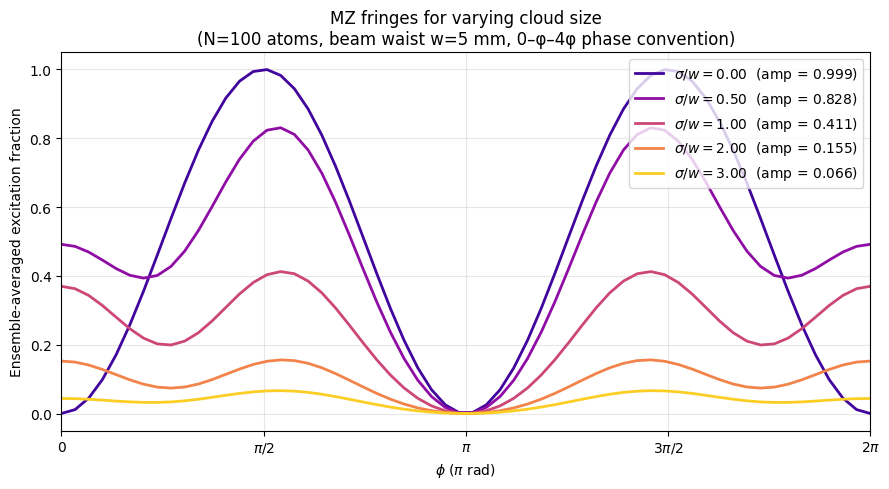

In [5]:
# Plot ensemble-averaged MZ fringes for 5 representative cloud sizes.
# fringe_curves was computed in the cell above.

selected_sw = [0.0, 0.5, 1.0, 2.0, 3.0]
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(selected_sw)))

fig, ax = plt.subplots(figsize=(9, 5))

for sw, color in zip(selected_sw, colors):
    # Find the closest computed sigma/w key
    closest_sw = min(fringe_curves.keys(), key=lambda k: abs(k - sw))
    exc_curve = fringe_curves[closest_sw]
    amp = exc_curve.max() - exc_curve.min()
    ax.plot(
        phi_vals / np.pi,
        exc_curve,
        color=color,
        linewidth=2,
        label=fr"$\sigma/w = {closest_sw:.2f}$  (amp = {amp:.3f})",
    )

ax.set_xlabel(r"$\phi$ ($\pi$ rad)")
ax.set_ylabel("Ensemble-averaged excitation fraction")
ax.set_title(
    f"MZ fringes for varying cloud size\n"
    f"(N={N_ATOMS} atoms, beam waist w={w*1e3:.0f} mm, 0\u2013\u03c6\u20134\u03c6 phase convention)"
)
ax.set_xticks([0, 0.5, 1, 1.5, 2], ["0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
ax.set_xlim(0, 2)
ax.set_ylim(-0.05, 1.05)
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
fig.tight_layout()

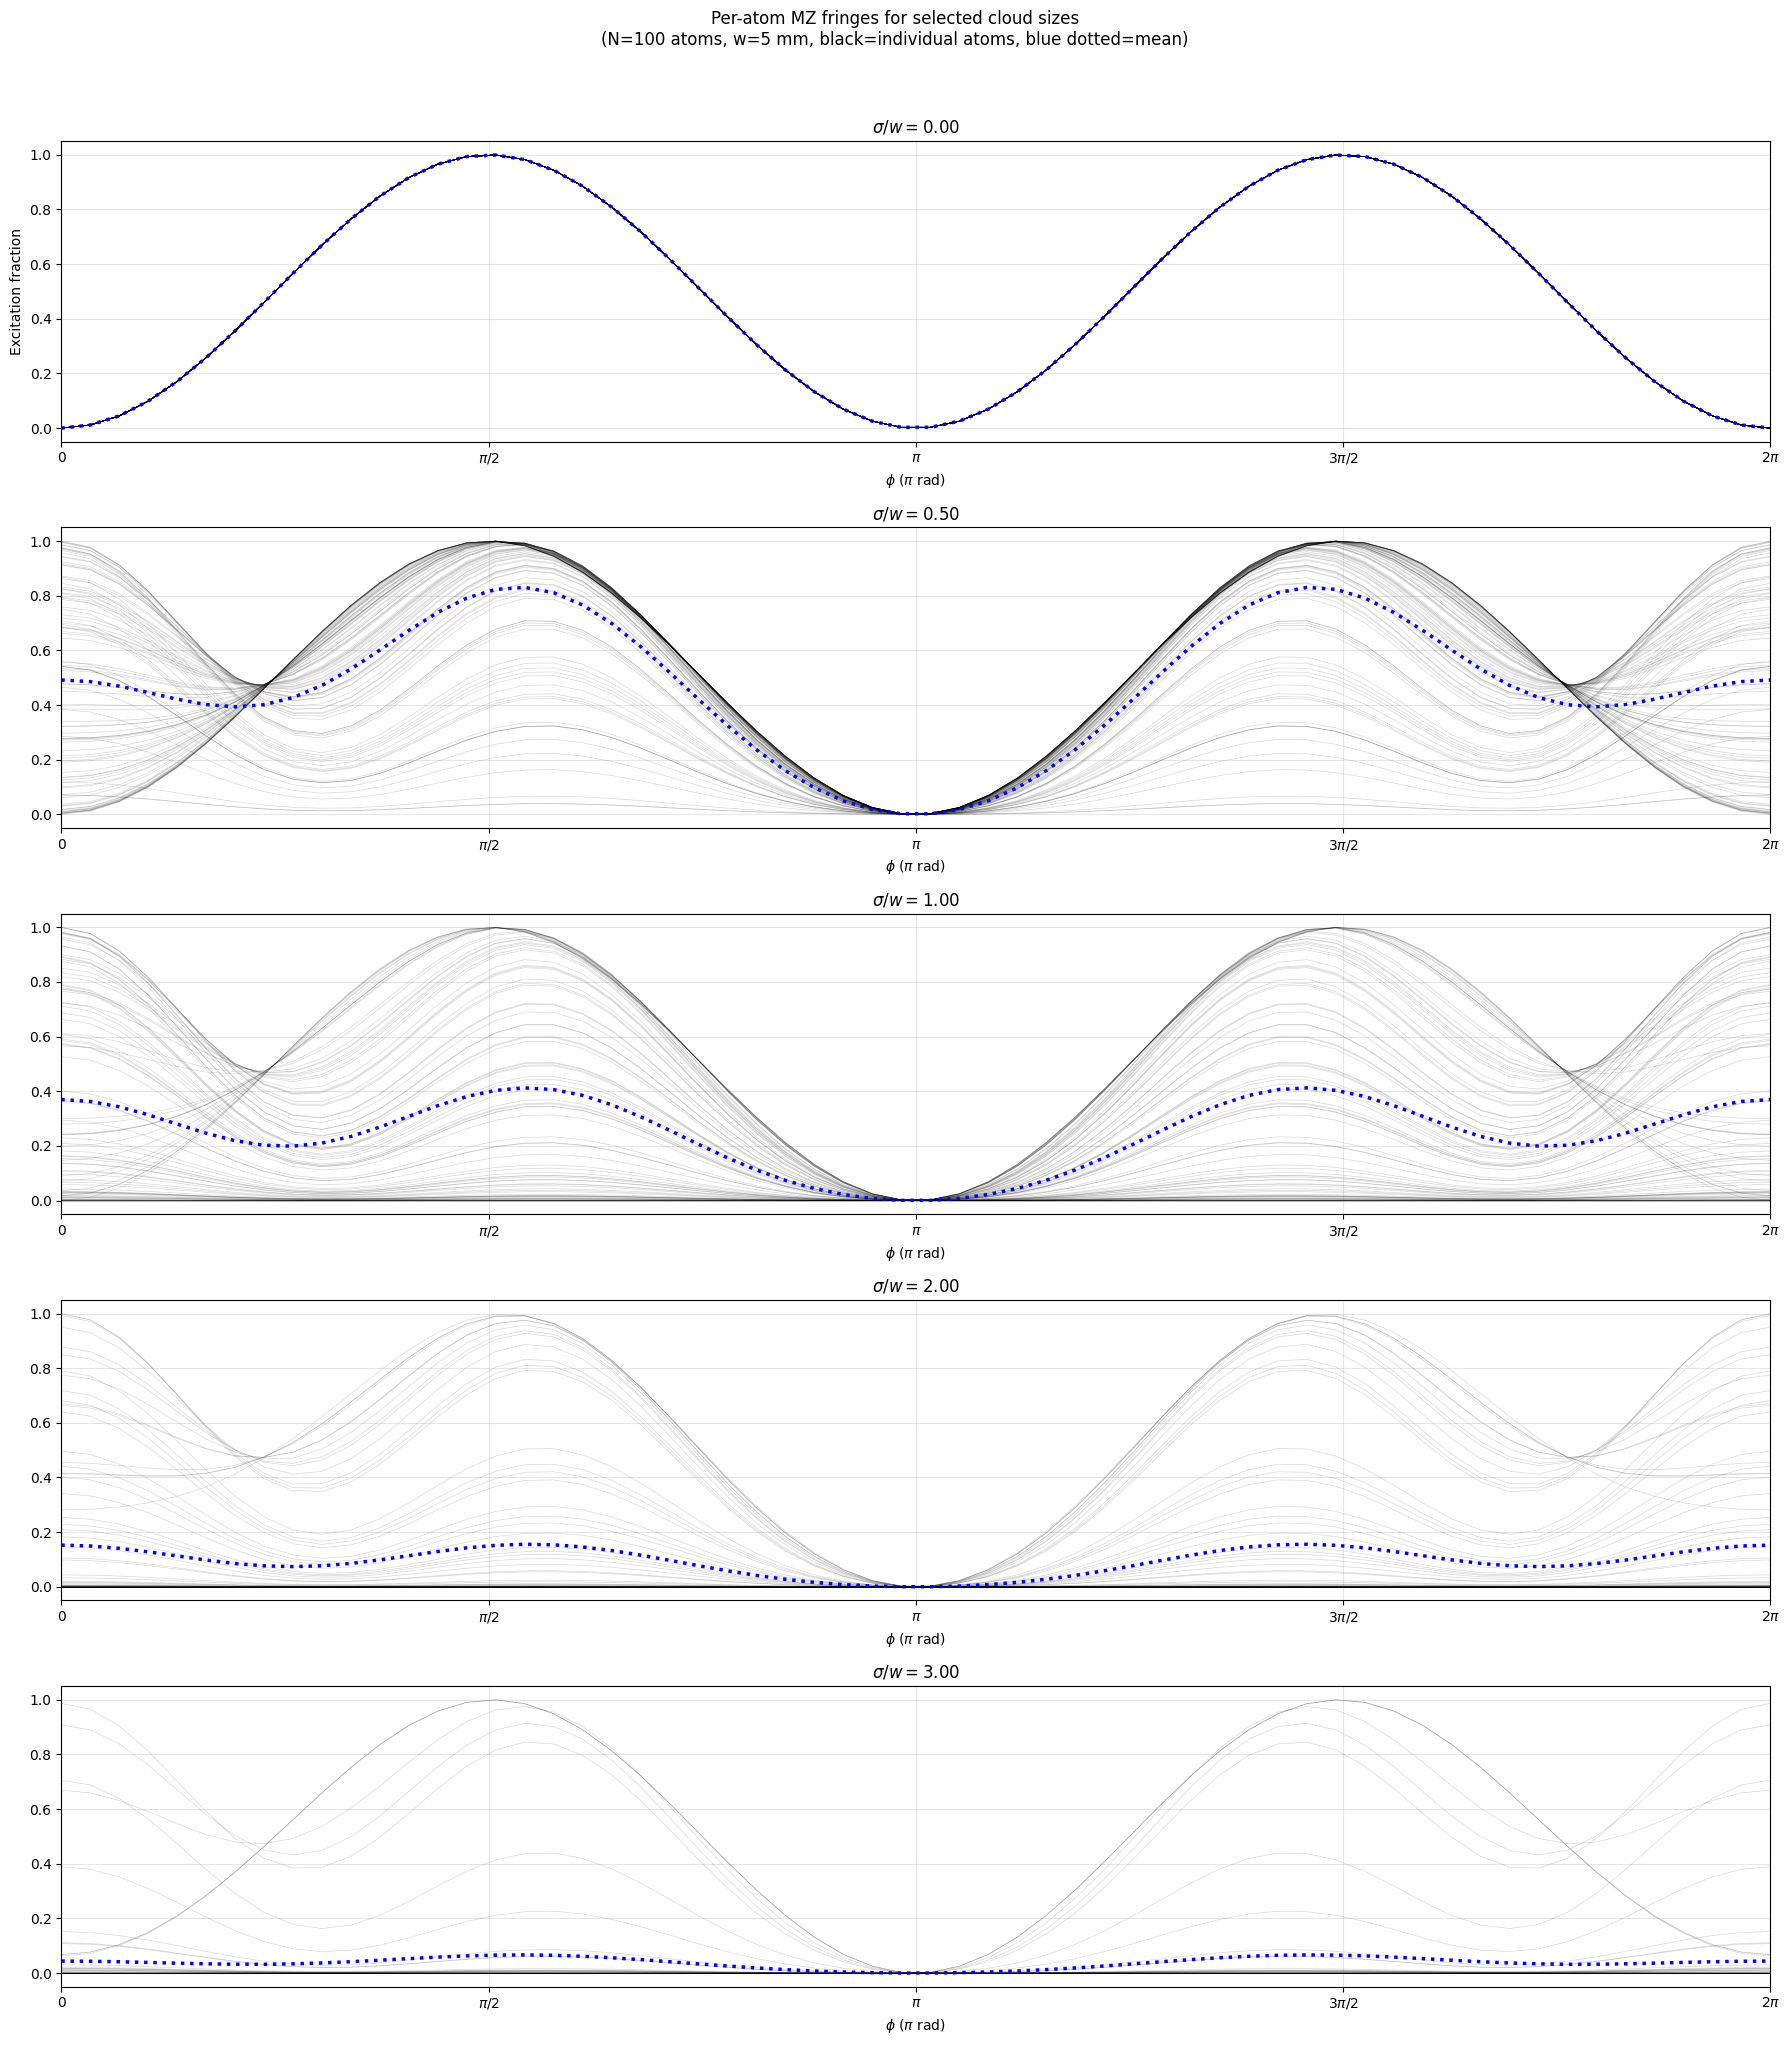

In [8]:
# Per-atom fringe plots for 5 representative cloud sizes.
# Each subplot shows every atom's fringe (thin black, transparent) plus
# the ensemble mean (thick dotted blue).

selected_sw = [0.0, 0.5, 1.0, 2.0, 3.0]

fig, axes = plt.subplots(5,1, figsize=(18, 20), sharey=True)

for ax, sw in zip(axes, selected_sw):
    closest_sw = min(fringe_per_atom.keys(), key=lambda k: abs(k - sw))
    per_atom = fringe_per_atom[closest_sw]   # shape (n_phi, n_atoms)
    mean_curve = fringe_curves[closest_sw]

    # Plot each atom's fringe
    for atom_idx in range(per_atom.shape[1]):
        ax.plot(
            phi_vals / np.pi,
            per_atom[:, atom_idx],
            color="black",
            linewidth=0.5,
            alpha=0.15,
        )

    # Overlay ensemble mean
    ax.plot(
        phi_vals / np.pi,
        mean_curve,
        color="blue",
        linewidth=2.5,
        linestyle=":",
        label="mean",
    )

    ax.set_title(fr"$\sigma/w = {closest_sw:.2f}$")
    ax.set_xlabel(r"$\phi$ ($\pi$ rad)")
    ax.set_xticks([0, 0.5, 1, 1.5, 2], ["0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
    ax.set_xlim(0, 2)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Excitation fraction")
fig.suptitle(
    f"Per-atom MZ fringes for selected cloud sizes\n"
    f"(N={N_ATOMS} atoms, w={w*1e3:.0f} mm, black=individual atoms, blue dotted=mean)",
    y=1.02,
)
fig.tight_layout()



## 4. Single $\pi$-pulse excitation vs cloud size

Sanity check: apply a single on-resonance $\pi$-pulse and measure the ensemble-averaged
excitation as a function of cloud sigma.

For a point-like cloud ($\sigma \to 0$), all atoms sit on-axis and see the full Rabi frequency,
so a $\pi$-pulse transfers them to the excited state: mean excitation $\approx 1$.

As the cloud size increases relative to the beam waist, atoms further from the axis
experience a weaker Rabi frequency and are only partially transferred.  The
ensemble-averaged excitation therefore **decreases** with cloud sigma, with the
characteristic scale set by the beam waist `w`.

This provides a clean, single-pulse diagnostic of inhomogeneous coupling that is
independent of interferometer phase.


Mean excitations: ['1.000', '0.997', '0.942', '0.845', '0.690', '0.666', '0.491', '0.287', '0.324', '0.251', '0.178', '0.181', '0.150', '0.143', '0.136', '0.098', '0.103', '0.054', '0.067', '0.066', '0.045', '0.061', '0.050', '0.026', '0.018']
On-axis mean excitation: 1.0000 (expected ~1.0)
Mean excitation at sigma=3w: 0.0184 (expected << on-axis)
Qualitative sanity check PASSED.


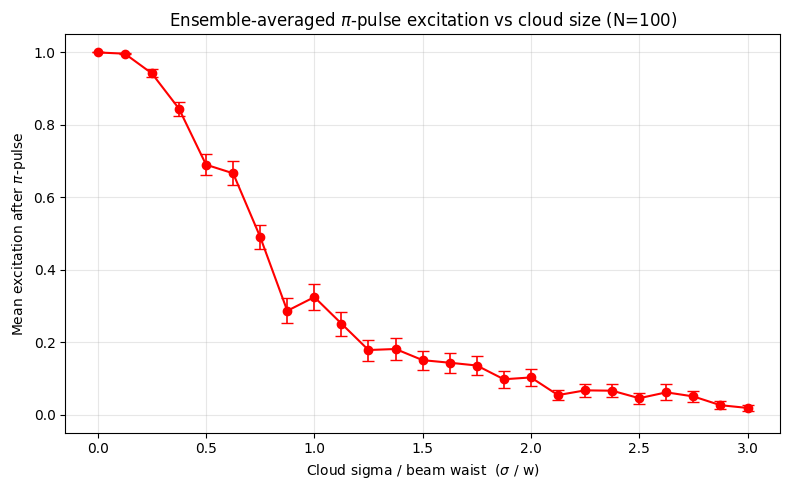

In [10]:
N_ATOMS_PI = 100
w_pi = 5e-3          # beam waist (m)
omega_laser_pi = 2 * np.pi * sim.TRANSITION_FREQUENCY

rng_pi = np.random.default_rng(0)

sigma_over_w_pi = np.linspace(0.0, 3.0, 25)
mean_excitations = []
std_errors = []

for sw in sigma_over_w_pi:
    sigma = sw * w_pi
    xy = rng_pi.normal(0.0, sigma, size=(N_ATOMS_PI, 2)) if sigma > 0 else np.zeros((N_ATOMS_PI, 2))

    exc_list = []
    for x, y in xy:
        m_values, positions, velocities, internal_amplitude, internal_is_ground = (
            sim.make_atom_states(position_x=x, position_y=y, c0=1.0, c1=0.0)
        )
        sq_amp = sim.transform_state_vector(
            m_values, internal_amplitude, internal_is_ground,
            omega_laser=omega_laser_pi, t=0.0, z=0.0, vz=0.0, inverse=False,
        )
        m_out, amp_out, isg_out, pos_out, vel_out = sim.do_gaussian_pulse(
            m_values, sq_amp, internal_is_ground,
            positions, velocities,
            pulse_detuning=sim.RECOIL_FREQUENCY_HZ,
            t_pulse=sim.T_PI,
            on_axis_rabi_freq=sim.RABI_FREQ,
            beam_waist=w_pi,
            vz=0.0,
        )
        amp_lab = sim.transform_state_vector(
            m_out, amp_out, isg_out,
            omega_laser=omega_laser_pi, t=sim.T_PI, z=0.0, vz=0.0, inverse=True,
        )
        _, exc = sim.calculate_ground_and_excited_probabilities(m_out, amp_lab, isg_out)
        exc_list.append(exc)

    exc_arr = np.array(exc_list)
    mean_excitations.append(exc_arr.mean())
    std_errors.append(exc_arr.std() / np.sqrt(len(exc_arr)))

mean_excitations = np.array(mean_excitations)
std_errors = np.array(std_errors)

plt.figure(figsize=(8, 5))
plt.errorbar(sigma_over_w_pi, mean_excitations, yerr=std_errors,
             fmt="ro-", markersize=6, capsize=4, elinewidth=1.2)
plt.xlabel(r"Cloud sigma / beam waist  ($\sigma$ / w)")
plt.ylabel(r"Mean excitation after $\pi$-pulse")
plt.title(r"Ensemble-averaged $\pi$-pulse excitation vs cloud size (N=100)")
plt.grid(True, alpha=0.3)
plt.ylim(-0.05, 1.05)
plt.tight_layout()


print("Mean excitations:", [f"{e:.3f}" for e in mean_excitations])
assert mean_excitations[0] > 0.99, (
    f"On-axis pi-pulse should give excitation ~1, got {mean_excitations[0]:.4f}"
)
assert mean_excitations[-1] < mean_excitations[0], (
    f"Large-cloud mean excitation ({mean_excitations[-1]:.4f}) should be less than on-axis ({mean_excitations[0]:.4f})"
)
print(f"On-axis mean excitation: {mean_excitations[0]:.4f} (expected ~1.0)")
print(f"Mean excitation at sigma=3w: {mean_excitations[-1]:.4f} (expected << on-axis)")
print("Qualitative sanity check PASSED.")


## Summary

- `gaussian_rabi` correctly implements the TEM00 profile.
- `do_gaussian_pulse` routes per-row Rabi frequencies through `pulse_interaction_in_borde_representation`.
- The MZ sequence follows the reference implementation in `mach_zehnder_with_temperature.ipynb`:
  laser phases are $0$, $\phi$, $4\phi$ and free-evolution uses `propagate_states_in_borde_representation`.
- As the cloud sigma grows relative to the beam waist, atoms further from the axis experience
  a weaker Rabi frequency and contribute ~0 excitation at every phase.  This reduces the
  **fringe amplitude** ($\max - \min$) with cloud size, as shown in the plots above.
- The Michelson contrast ($\max - \min$)/($\max + \min$) remains near 1 for all cloud sizes because
  the minimum excitation also trends to zero alongside the maximum; it is therefore not a
  meaningful metric here.  The physically relevant quantity is the fringe **amplitude**.
